### **Car Dataset**



*   NAME: Sneha Rawat
*   ROLL NO: 2K24CSUN01134
*   CLASS: CSE 4B



**Importing Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Loading the Dataset**

In [ ]:
file_path = '/content/car_dataset.csv'
df = pd.read_csv(file_path, header=None)
column_names = [
    'symboling', 'normalized_losses', 'make', 'fuel_type', 'aspiration',
    'num_doors', 'body_style', 'drive_wheels', 'engine_location',
    'wheel_base', 'length', 'width', 'height', 'curb_weight',
    'engine_type', 'num_cylinders', 'engine_size', 'fuel_system',
    'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm',
    'city_mpg', 'highway_mpg', 'price'
]
df.columns = column_names
print(df)

     symboling normalized_losses         make fuel_type aspiration num_doors  \
0            3                 ?  alfa-romero       gas        std       two   
1            3                 ?  alfa-romero       gas        std       two   
2            1                 ?  alfa-romero       gas        std       two   
3            2               164         audi       gas        std      four   
4            2               164         audi       gas        std      four   
..         ...               ...          ...       ...        ...       ...   
200         -1                95        volvo       gas        std      four   
201         -1                95        volvo       gas      turbo      four   
202         -1                95        volvo       gas        std      four   
203         -1                95        volvo    diesel      turbo      four   
204         -1                95        volvo       gas      turbo      four   

      body_style drive_wheels engine_lo

**Initial Data Inspection**

In [ ]:
print("First 5 rows:")
print(df.head())

print("\n" + "="*50)
print("Data Info:")
df.info()

print("\n" + "="*50)
print("Basic Statistics:")
print(df.describe())

First 5 rows:
   symboling normalized_losses         make fuel_type aspiration num_doors  \
0          3                 ?  alfa-romero       gas        std       two   
1          3                 ?  alfa-romero       gas        std       two   
2          1                 ?  alfa-romero       gas        std       two   
3          2               164         audi       gas        std      four   
4          2               164         audi       gas        std      four   

    body_style drive_wheels engine_location  wheel_base  ...  engine_size  \
0  convertible          rwd           front        88.6  ...          130   
1  convertible          rwd           front        88.6  ...          130   
2    hatchback          rwd           front        94.5  ...          152   
3        sedan          fwd           front        99.8  ...          109   
4        sedan          4wd           front        99.4  ...          136   

   fuel_system  bore  stroke compression_ratio horsepo

**Handling Missing Values**

In [ ]:
df = df.replace('?', np.nan)

numeric_cols = ['normalized_losses', 'bore', 'stroke', 'horsepower',
                'peak_rpm', 'price', 'symboling']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Missing values per column:
normalized_losses    41
num_doors             2
bore                  4
stroke                4
horsepower            2
peak_rpm              2
price                 4
dtype: int64

Total missing values: 59


**Remove Duplicates**

In [ ]:
print(f"Duplicate rows: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Shape after removing duplicates: {df.shape}")

Duplicate rows: 0
Shape after removing duplicates: (205, 26)


**Text Data Cleaning**

In [ ]:
df = df.dropna(subset=['price'])
num_cols_with_na = ['normalized_losses', 'bore', 'stroke', 'horsepower', 'peak_rpm']
for col in num_cols_with_na:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)
    print(f"Filled {col} with median: {median_val}")

cat_cols_with_na = ['num_doors']
for col in cat_cols_with_na:
    mode_val = df[col].mode()[0]
    df[col].fillna(mode_val, inplace=True)
    print(f"Filled {col} with mode: {mode_val}")

Filled normalized_losses with median: 115.0
Filled bore with median: 3.31
Filled stroke with median: 3.29
Filled horsepower with median: 95.0
Filled peak_rpm with median: 5200.0
Filled num_doors with mode: four


/tmp/ipykernel_3447/798481182.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)
/tmp/ipykernel_3447/798481182.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df

**Text Data Cleaning**

In [ ]:
text_columns = ['make', 'fuel_type', 'aspiration', 'num_doors',
                'body_style', 'drive_wheels', 'engine_location',
                'engine_type', 'fuel_system']

for col in text_columns:
    df[col] = df[col].str.lower().str.strip()

print("Unique values in categorical columns:")
for col in text_columns:
    print(f"{col}: {df[col].nunique()} unique values")

Unique values in categorical columns:
make: 22 unique values
fuel_type: 2 unique values
aspiration: 2 unique values
num_doors: 2 unique values
body_style: 5 unique values
drive_wheels: 3 unique values
engine_location: 2 unique values
engine_type: 6 unique values
fuel_system: 8 unique values


**Feature Engineering**

In [ ]:
df['power_to_weight'] = df['horsepower'] / df['curb_weight']
df['volume'] = df['length'] * df['width'] * df['height']
df['avg_mpg'] = (df['city_mpg'] + df['highway_mpg']) / 2

df.head()

,symboling,normalized_losses,make,fuel_type,aspiration,num_doors,body_style,drive_wheels,engine_location,wheel_base,...,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price,power_to_weight,volume,avg_mpg
0,3,115.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,2.68,9.0,111.0,5000.0,21,27,13495.0,0.043564,528019.904,24.0
1,3,115.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,2.68,9.0,111.0,5000.0,21,27,16500.0,0.043564,528019.904,24.0
2,1,115.0,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,3.47,9.0,154.0,5000.0,19,26,16500.0,0.054552,587592.640,22.5
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,3.40,10.0,102.0,5500.0,24,30,13950.0,0.043646,634816.956,27.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,3.40,8.0,115.0,5500.0,18,22,17450.0,0.040722,636734.832,20.0


**Handle Outliers**

In [ ]:
def remove_outliers_iqr(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = dataframe[(dataframe[column] < lower_bound) | (dataframe[column] > upper_bound)]
    print(f"{column}: {len(outliers)} outliers found (bounds: {lower_bound:.2f} to {upper_bound:.2f})")

    # Cap the outliers instead of removing (winsorization)
    dataframe[column] = dataframe[column].clip(lower=lower_bound, upper=upper_bound)
    return dataframe

outlier_cols = ['price', 'horsepower', 'curb_weight', 'engine_size']

for col in outlier_cols:
    df = remove_outliers_iqr(df, col)

price: 14 outliers found (bounds: -5312.50 to 29587.50)
horsepower: 5 outliers found (bounds: 1.00 to 185.00)
curb_weight: 2 outliers found (bounds: 1033.50 to 4061.50)
engine_size: 10 outliers found (bounds: 33.50 to 205.50)


**Binning/Discretization**

In [ ]:
df['price_category'] = pd.cut(df['price'],
                               bins=[0, 10000, 20000, 30000, float('inf')],
                               labels=['budget', 'mid_range', 'premium', 'luxury'])

df['power_category'] = pd.cut(df['horsepower'],
                               bins=[0, 100, 150, 200, float('inf')],
                               labels=['low', 'medium', 'high', 'very_high'])

df['weight_class'] = pd.cut(df['curb_weight'],
                             bins=3,
                             labels=['light', 'medium', 'heavy'])

print("\nPower category distribution:")
print(df['power_category'].value_counts())


Power category distribution:
power_category
low          111
medium        60
high          30
very_high      0
Name: count, dtype: int64


**Data Visualizations**

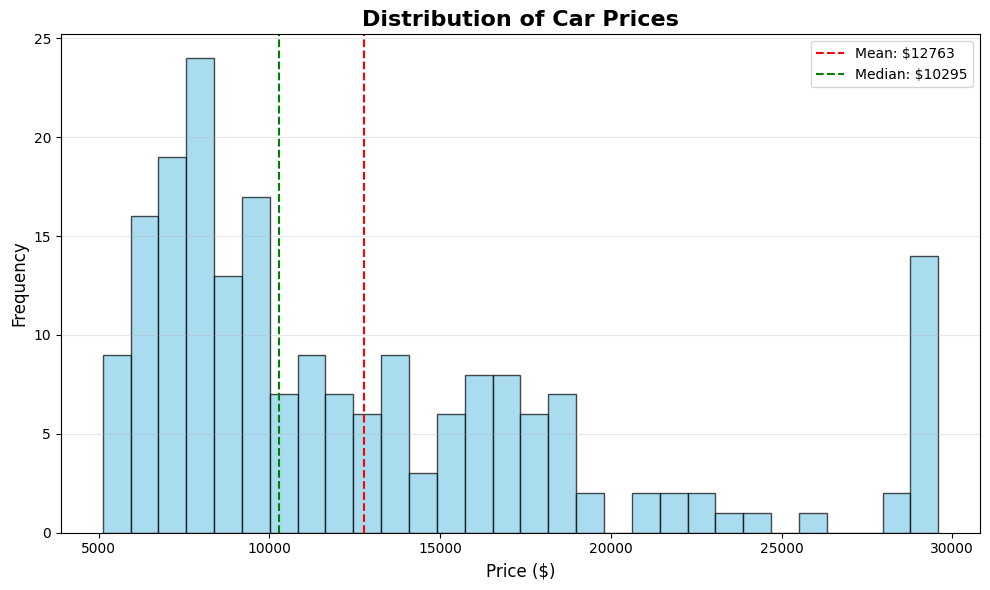

Price Statistics:
Mean: $12762.78
Median: $10295.00
Min: $5118.00
Max: $29587.50


In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(df['price'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Distribution of Car Prices', fontsize=16, fontweight='bold')
plt.xlabel('Price ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.axvline(df['price'].mean(), color='red', linestyle='--', label=f'Mean: ${df["price"].mean():.0f}')
plt.axvline(df['price'].median(), color='green', linestyle='--', label=f'Median: ${df["price"].median():.0f}')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Price Statistics:")
print(f"Mean: ${df['price'].mean():.2f}")
print(f"Median: ${df['price'].median():.2f}")
print(f"Min: ${df['price'].min():.2f}")
print(f"Max: ${df['price'].max():.2f}")

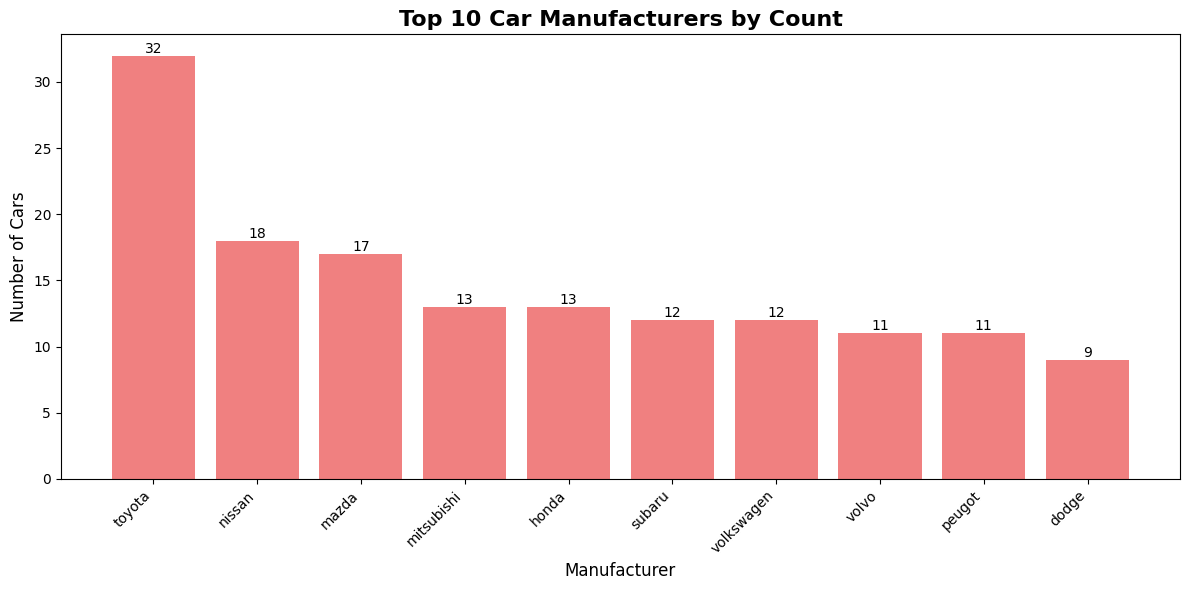

In [ ]:
plt.figure(figsize=(12, 6))
make_counts = df['make'].value_counts().head(10)
bars = plt.bar(make_counts.index, make_counts.values, color='lightcoral')
plt.title('Top 10 Car Manufacturers by Count', fontsize=16, fontweight='bold')
plt.xlabel('Manufacturer', fontsize=12)
plt.ylabel('Number of Cars', fontsize=12)
plt.xticks(rotation=45, ha='right')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom')

plt.tight_layout()
plt.show()

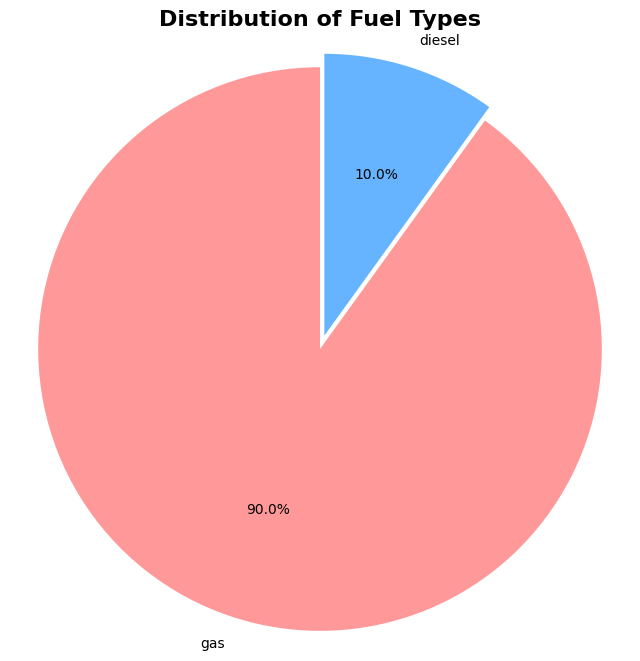

Fuel Type Counts:
fuel_type
gas       181
diesel     20
Name: count, dtype: int64


In [ ]:
plt.figure(figsize=(8, 8))
fuel_counts = df['fuel_type'].value_counts()
colors = ['#ff9999', '#66b3ff']
plt.pie(fuel_counts.values, labels=fuel_counts.index, autopct='%1.1f%%',
        colors=colors, startangle=90, explode=[0.05, 0])
plt.title('Distribution of Fuel Types', fontsize=16, fontweight='bold')
plt.axis('equal')
plt.show()

print(f"Fuel Type Counts:")
print(fuel_counts)

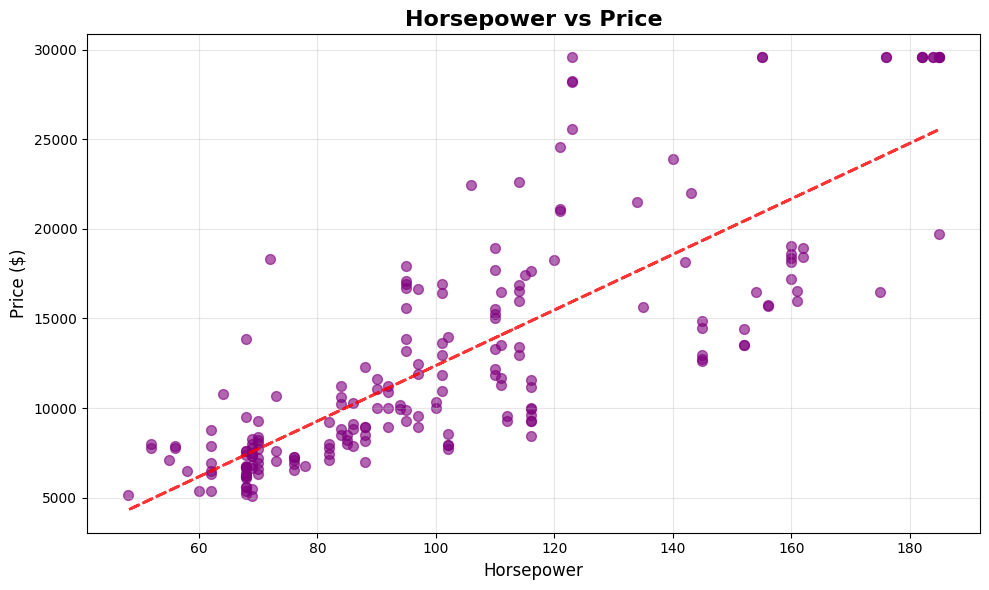

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df['horsepower'], df['price'], alpha=0.6, color='purple', s=50)
plt.title('Horsepower vs Price', fontsize=16, fontweight='bold')
plt.xlabel('Horsepower', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.grid(True, alpha=0.3)

z = np.polyfit(df['horsepower'].dropna(), df['price'][df['horsepower'].notna()], 1)
p = np.poly1d(z)
plt.plot(df['horsepower'], p(df['horsepower']), "r--", alpha=0.8, linewidth=2)

plt.tight_layout()
plt.show()